In [2]:
# === INSTALL DEPENDENCIES IF NEEDED ===
# pip install pandas scikit-learn tensorflow openpyxl

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# === LOAD DATA ===
file_path = "mmc2.xlsx"  # Make sure your file is in the working directory
df = pd.read_excel(r"E:\project_dv\paper1\mmc2.xlsx")
# === DEFINE COLUMNS ===
social_columns = df.columns[1:21].tolist()

phq9_columns = [
    "1 In the last 30 days, little interest or pleasure in doing things.",
    "2. In the last 30 days, feeling down, depressed or hopeless.",
    "3. In the last 30 days, trouble falling or staying asleep, sleeping too much",
    "4. In the last 30 days, Feeling tired or having little energy.",
    "5. In the last 30 days, poor appetite or over-eating.",
    "6. In the last 30 days, feeling bad about yourself-or that you are a failure or have let yourself or your family down.",
    "7. In the last 30 days, trouble concentrating on things, such as reading the newspaper or watching television.",
    "8. In the last 30 days, moving or speaking so slowly or the opposite-moving around a lot more than usual.",
    "9. In the last 30 days, thoughts that you would be better off dead, or of hurting yourself."
]

gad7_columns = [
    "1. In the last 30 days, I am feeling nervous, anxious, or on edge",
    "2. In the last 30 days, I an not being able to stop or control worrying",
    "3. In the last 30 days, I am worrying too much about different things.",
    "4. In the last 30 days, I felt trouble in relaxing.",
    "5. In the last 30 days, I am being so restless that it's hard to sit still",
    "6. In the last 30 days, I becoming easily annoyed or irritable.",
    "7. In the last 30 days, I am feeling afraid as if something awful might happen."
]

# === STANDARDIZE RESPONSES ===
response_fix = {
    "Not at all": 0,
    "Several days": 1,
    "Half of days": 2,
    "Half days": 2,
    "More than half the days": 2,
    "Nearly everyday": 3,
    "Nearly every day": 3
}

df[phq9_columns] = df[phq9_columns].replace(response_fix)
df[gad7_columns] = df[gad7_columns].replace(response_fix)

# === SCORE TARGETS ===
df["phq_score"] = df[phq9_columns].sum(axis=1)
df["gad_score"] = df[gad7_columns].sum(axis=1)

# === PREPARE DATA ===
data = df[social_columns + ["phq_score", "gad_score"]].dropna()
X = pd.get_dummies(data[social_columns], drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === SPLIT DATA ===
X_train_phq, X_test_phq, y_train_phq, y_test_phq = train_test_split(X_scaled, data["phq_score"], test_size=0.2, random_state=42)
X_train_gad, X_test_gad, y_train_gad, y_test_gad = train_test_split(X_scaled, data["gad_score"], test_size=0.2, random_state=42)

# === BUILD NEURAL NETWORK ===
def build_deep_model(input_dim):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

# PHQ-9 MODEL
model_phq = build_deep_model(X_train_phq.shape[1])
model_phq.fit(X_train_phq, y_train_phq, epochs=100, batch_size=32, verbose=0)

# GAD-7 MODEL
model_gad = build_deep_model(X_train_gad.shape[1])
model_gad.fit(X_train_gad, y_train_gad, epochs=100, batch_size=32, verbose=0)

# === EVALUATE ===
y_pred_phq = model_phq.predict(X_test_phq).flatten()
y_pred_gad = model_gad.predict(X_test_gad).flatten()

print("\n📊 PHQ-9 Results")
print("MAE:", mean_absolute_error(y_test_phq, y_pred_phq))
print("RMSE:", np.sqrt(mean_squared_error(y_test_phq, y_pred_phq)))
print("R2:", r2_score(y_test_phq, y_pred_phq))

print("\n📊 GAD-7 Results")
print("MAE:", mean_absolute_error(y_test_gad, y_pred_gad))
print("RMSE:", np.sqrt(mean_squared_error(y_test_gad, y_pred_gad)))
print("R2:", r2_score(y_test_gad, y_pred_gad))


5/5 [==============================] - 0s 0s/step

📊 PHQ-9 Results
MAE: 5.219194977538391
RMSE: 6.684790670008501
R2: -0.1549863343597555

📊 GAD-7 Results
MAE: 5.587821005275415
RMSE: 7.655277562216246
R2: -0.6448026236187812


📊 PHQ-9 Classification Report:

                   precision    recall  f1-score   support

             Mild       0.38      0.69      0.49        58
          Minimal       0.36      0.29      0.32        45
         Moderate       0.21      0.10      0.14        29
Moderately Severe       0.40      0.13      0.20        15
           Severe       0.00      0.00      0.00        12

         accuracy                           0.36       159
        macro avg       0.27      0.24      0.23       159
     weighted avg       0.32      0.36      0.32       159

📊 GAD-7 Classification Report:

              precision    recall  f1-score   support

        Mild       0.32      0.40      0.36        47
     Minimal       0.47      0.63      0.54        63
    Moderate       0.17      0.03      0.06        30
      Severe       0.50      0.21      0.30        19

    accuracy                           0.40       159
   macro avg       0.36      0.32      0.31       159
weighted avg       0.3

c:\Users\rohan\anaconda3\envs\deep-learning-env\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\rohan\anaconda3\envs\deep-learning-env\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\rohan\anaconda3\envs\deep-learning-env\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start,

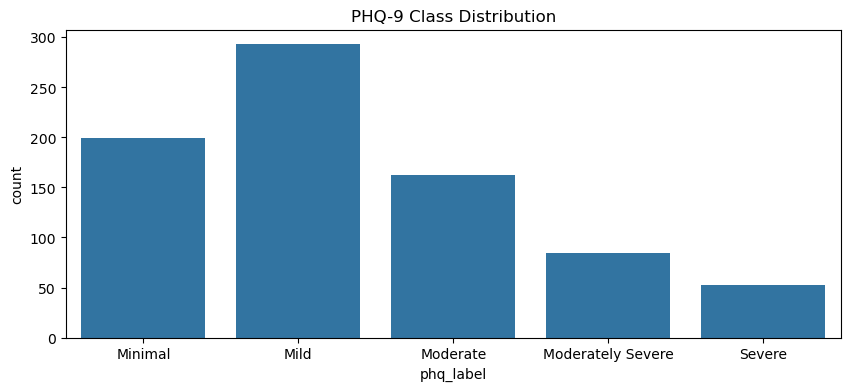

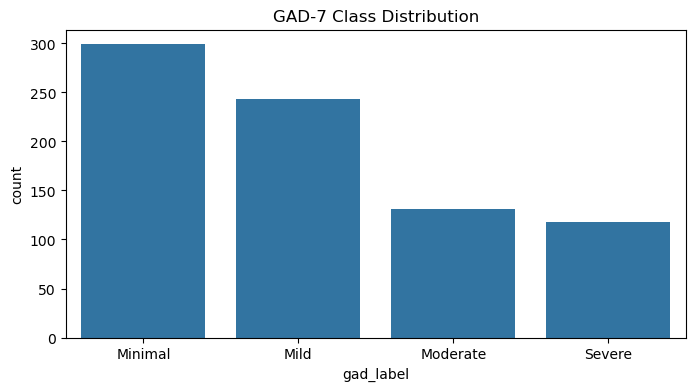

In [3]:
# 📦 Install required packages (if not already installed)
# pip install pandas scikit-learn openpyxl

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# === LOAD DATA ===
#df = pd.read_excel("mmc2.xlsx", sheet_name="Raw Data")

# === DEFINE RELEVANT COLUMNS ===
social_columns = df.columns[1:21].tolist()

phq9_columns = [
    "1 In the last 30 days, little interest or pleasure in doing things.",
    "2. In the last 30 days, feeling down, depressed or hopeless.",
    "3. In the last 30 days, trouble falling or staying asleep, sleeping too much",
    "4. In the last 30 days, Feeling tired or having little energy.",
    "5. In the last 30 days, poor appetite or over-eating.",
    "6. In the last 30 days, feeling bad about yourself-or that you are a failure or have let yourself or your family down.",
    "7. In the last 30 days, trouble concentrating on things, such as reading the newspaper or watching television.",
    "8. In the last 30 days, moving or speaking so slowly or the opposite-moving around a lot more than usual.",
    "9. In the last 30 days, thoughts that you would be better off dead, or of hurting yourself."
]

gad7_columns = [
    "1. In the last 30 days, I am feeling nervous, anxious, or on edge",
    "2. In the last 30 days, I an not being able to stop or control worrying",
    "3. In the last 30 days, I am worrying too much about different things.",
    "4. In the last 30 days, I felt trouble in relaxing.",
    "5. In the last 30 days, I am being so restless that it's hard to sit still",
    "6. In the last 30 days, I becoming easily annoyed or irritable.",
    "7. In the last 30 days, I am feeling afraid as if something awful might happen."
]

# === STANDARDIZE TEXT RESPONSES ===
ordinal_map = {
    "Not at all": 0,
    "Several days": 1,
    "Half of days": 2,
    "Half days": 2,
    "More than half the days": 2,
    "Nearly everyday": 3,
    "Nearly every day": 3
}

df[phq9_columns] = df[phq9_columns].replace(ordinal_map)
df[gad7_columns] = df[gad7_columns].replace(ordinal_map)

# === CALCULATE TOTAL SCORES ===
df["phq_score"] = df[phq9_columns].sum(axis=1)
df["gad_score"] = df[gad7_columns].sum(axis=1)

# === CLASSIFY BASED ON SCORE SEVERITY ===
def phq_label(score):
    if score <= 4:
        return "Minimal"
    elif score <= 9:
        return "Mild"
    elif score <= 14:
        return "Moderate"
    elif score <= 19:
        return "Moderately Severe"
    else:
        return "Severe"

def gad_label(score):
    if score <= 4:
        return "Minimal"
    elif score <= 9:
        return "Mild"
    elif score <= 14:
        return "Moderate"
    else:
        return "Severe"

df["phq_label"] = df["phq_score"].apply(phq_label)
df["gad_label"] = df["gad_score"].apply(gad_label)

# === ENCODE TARGET LABELS ===
le_phq = LabelEncoder()
le_gad = LabelEncoder()
df["phq_encoded"] = le_phq.fit_transform(df["phq_label"])
df["gad_encoded"] = le_gad.fit_transform(df["gad_label"])

# === PREPARE FEATURES ===
X = pd.get_dummies(df[social_columns], drop_first=True)
y_phq = df.loc[X.index, "phq_encoded"]
y_gad = df.loc[X.index, "gad_encoded"]

# === SPLIT & TRAIN PHQ-9 CLASSIFIER ===
X_train_phq, X_test_phq, y_train_phq, y_test_phq = train_test_split(X, y_phq, test_size=0.2, random_state=42)
clf_phq = RandomForestClassifier(n_estimators=100, random_state=42)
clf_phq.fit(X_train_phq, y_train_phq)
y_pred_phq = clf_phq.predict(X_test_phq)

# === SPLIT & TRAIN GAD-7 CLASSIFIER ===
X_train_gad, X_test_gad, y_train_gad, y_test_gad = train_test_split(X, y_gad, test_size=0.2, random_state=42)
clf_gad = RandomForestClassifier(n_estimators=100, random_state=42)
clf_gad.fit(X_train_gad, y_train_gad)
y_pred_gad = clf_gad.predict(X_test_gad)

# === EVALUATION ===
print("📊 PHQ-9 Classification Report:\n")
print(classification_report(y_test_phq, y_pred_phq, target_names=le_phq.classes_))

print("📊 GAD-7 Classification Report:\n")
print(classification_report(y_test_gad, y_pred_gad, target_names=le_gad.classes_))

# === OPTIONAL: Plot Distribution ===
plt.figure(figsize=(10,4))
sns.countplot(data=df, x="phq_label", order=["Minimal", "Mild", "Moderate", "Moderately Severe", "Severe"])
plt.title("PHQ-9 Class Distribution")
plt.show()

plt.figure(figsize=(8,4))
sns.countplot(data=df, x="gad_label", order=["Minimal", "Mild", "Moderate", "Severe"])
plt.title("GAD-7 Class Distribution")
plt.show()


In [ ]:
# 📦 Install if not done
# pip install pandas scikit-learn tensorflow openpyxl

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# === LOAD DATA ===
# df = pd.read_excel("mmc2.xlsx", sheet_name="Raw Data")

# === DEFINE COLUMNS ===
social_columns = df.columns[1:21].tolist()

phq9_columns = [
    "1 In the last 30 days, little interest or pleasure in doing things.",
    "2. In the last 30 days, feeling down, depressed or hopeless.",
    "3. In the last 30 days, trouble falling or staying asleep, sleeping too much",
    "4. In the last 30 days, Feeling tired or having little energy.",
    "5. In the last 30 days, poor appetite or over-eating.",
    "6. In the last 30 days, feeling bad about yourself-or that you are a failure or have let yourself or your family down.",
    "7. In the last 30 days, trouble concentrating on things, such as reading the newspaper or watching television.",
    "8. In the last 30 days, moving or speaking so slowly or the opposite-moving around a lot more than usual.",
    "9. In the last 30 days, thoughts that you would be better off dead, or of hurting yourself."
]

gad7_columns = [
    "1. In the last 30 days, I am feeling nervous, anxious, or on edge",
    "2. In the last 30 days, I an not being able to stop or control worrying",
    "3. In the last 30 days, I am worrying too much about different things.",
    "4. In the last 30 days, I felt trouble in relaxing.",
    "5. In the last 30 days, I am being so restless that it's hard to sit still",
    "6. In the last 30 days, I becoming easily annoyed or irritable.",
    "7. In the last 30 days, I am feeling afraid as if something awful might happen."
]

# === SCORING MAP ===
likert_map = {
    "Not at all": 0,
    "Several days": 1,
    "Half of days": 2,
    "Half days": 2,
    "More than half the days": 2,
    "Nearly everyday": 3,
    "Nearly every day": 3
}
df[phq9_columns] = df[phq9_columns].replace(likert_map)
df[gad7_columns] = df[gad7_columns].replace(likert_map)

# === SCORE PHQ-9 & GAD-7 ===
df["phq_score"] = df[phq9_columns].sum(axis=1)
df["gad_score"] = df[gad7_columns].sum(axis=1)

# === CATEGORICAL LABELS ===
def phq_category(score):
    if score <= 4:
        return "Minimal"
    elif score <= 9:
        return "Mild"
    elif score <= 14:
        return "Moderate"
    elif score <= 19:
        return "Moderately Severe"
    else:
        return "Severe"

def gad_category(score):
    if score <= 4:
        return "Minimal"
    elif score <= 9:
        return "Mild"
    elif score <= 14:
        return "Moderate"
    else:
        return "Severe"

df["phq_label"] = df["phq_score"].apply(phq_category)
df["gad_label"] = df["gad_score"].apply(gad_category)

# === ENCODING LABELS ===
le_phq = LabelEncoder()
le_gad = LabelEncoder()
df["phq_encoded"] = le_phq.fit_transform(df["phq_label"])
df["gad_encoded"] = le_gad.fit_transform(df["gad_label"])

# === PREPARE DATA ===
X = pd.get_dummies(df[social_columns], drop_first=True)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === SPLIT PHQ-9 ===
X_train_phq, X_test_phq, y_train_phq, y_test_phq = train_test_split(X_scaled, df["phq_encoded"], test_size=0.2, random_state=42)

# === SPLIT GAD-7 ===
X_train_gad, X_test_gad, y_train_gad, y_test_gad = train_test_split(X_scaled, df["gad_encoded"], test_size=0.2, random_state=42)

# === BUILD NEURAL NETWORK ===
def build_nn_classifier(output_dim):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X.shape[1],)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(output_dim, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# === TRAIN PHQ-9 MODEL ===
model_phq = build_nn_classifier(len(le_phq.classes_))
model_phq.fit(X_train_phq, y_train_phq, epochs=100, batch_size=32, verbose=0)
y_pred_phq = np.argmax(model_phq.predict(X_test_phq), axis=1)

# === TRAIN GAD-7 MODEL ===
model_gad = build_nn_classifier(len(le_gad.classes_))
model_gad.fit(X_train_gad, y_train_gad, epochs=100, batch_size=32, verbose=0)
y_pred_gad = np.argmax(model_gad.predict(X_test_gad), axis=1)

# === REPORTS ===
print("\n📊 PHQ-9 Classification Report:\n")
print(classification_report(y_test_phq, y_pred_phq, target_names=le_phq.classes_))

print("\n📊 GAD-7 Classification Report:\n")
print(classification_report(y_test_gad, y_pred_gad, target_names=le_gad.classes_))


5/5 [==============================] - 0s 1ms/step

📊 PHQ-9 Classification Report:

                   precision    recall  f1-score   support

             Mild       0.41      0.47      0.44        58
          Minimal       0.39      0.40      0.40        45
         Moderate       0.24      0.24      0.24        29
Moderately Severe       0.30      0.20      0.24        15
           Severe       0.38      0.25      0.30        12

         accuracy                           0.36       159
        macro avg       0.34      0.31      0.32       159
     weighted avg       0.36      0.36      0.36       159


📊 GAD-7 Classification Report:

              precision    recall  f1-score   support

        Mild       0.31      0.36      0.33        47
     Minimal       0.48      0.46      0.47        63
    Moderate       0.23      0.17      0.19        30
      Severe       0.23      0.26      0.24        19

    accuracy                           0.35       159
   macro avg       0.31